In [1]:
!pip install -q mlflow scikit-learn pandas matplotlib seaborn joblib

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import joblib

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

os.makedirs("datos/datos_ini", exist_ok=True)
os.makedirs("datos/datos_limp", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("fuentes", exist_ok=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 869.6 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/939.7 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214

In [2]:

data = load_breast_cancer()

df_raw = pd.DataFrame(data.data, columns=data.feature_names)
df_raw["target"] = data.target

df_raw.to_csv("datos/datos_ini/breast_cancer_raw.csv", index=False)

df_raw.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:

print("Dimensiones:", df_raw.shape)
print("\nValores nulos:")
print(df_raw.isnull().sum().sum())

print("\nDuplicados:", df_raw.duplicated().sum())

print("\nDistribución de clases:")
print(df_raw["target"].value_counts())

df_raw.describe()

Dimensiones: (569, 31)

Valores nulos:
0

Duplicados: 0

Distribución de clases:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [4]:

df_clean = df_raw.copy()

# eliminamos duplicados
df_clean = df_clean.drop_duplicates()

# validamos nulos
df_clean = df_clean.dropna()

df_clean.to_csv("datos/datos_limp/breast_cancer_clean.csv", index=False)

print("Dataset original:", df_raw.shape)
print("Dataset limpio:", df_clean.shape)

Dataset original: (569, 31)
Dataset limpio: (569, 31)


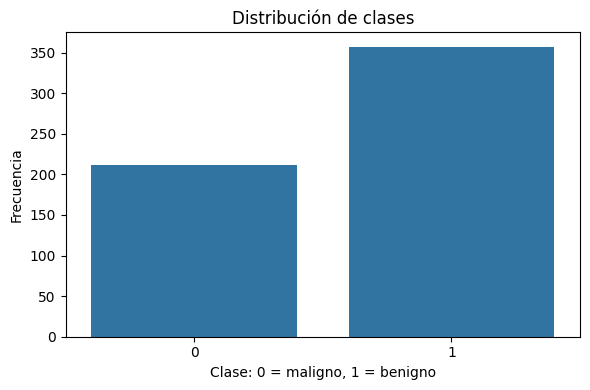

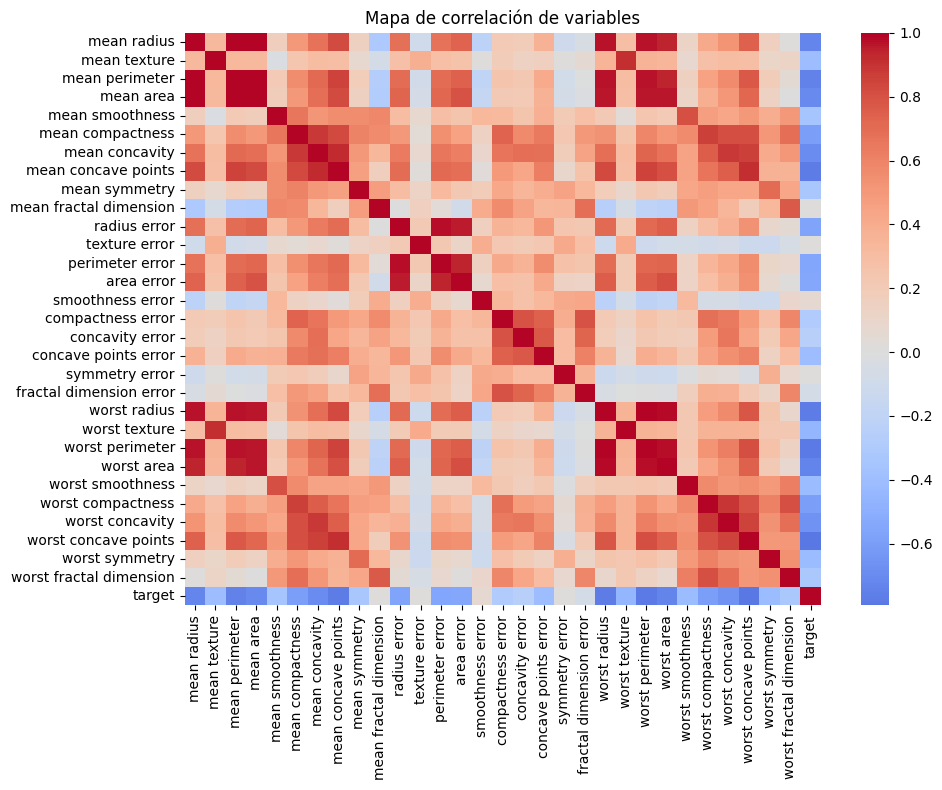

In [5]:

plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df_clean)
plt.title("Distribución de clases")
plt.xlabel("Clase: 0 = maligno, 1 = benigno")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("results/distribucion_clases.png")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df_clean.corr(), cmap="coolwarm", center=0)
plt.title("Mapa de correlación de variables")
plt.tight_layout()
plt.savefig("results/correlacion_variables.png")
plt.show()

In [6]:

X = df_clean.drop("target", axis=1)
y = df_clean["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (455, 30)
Test: (114, 30)


In [7]:

import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Actividad5_BreastCancer_Classification")

print("MLflow configurado con SQLite.")

2026/06/21 19:39:46 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/21 19:39:46 INFO mlflow.store.db.utils: Updating database tables
2026/06/21 19:39:48 INFO mlflow.tracking.fluent: Experiment with name 'Actividad5_BreastCancer_Classification' does not exist. Creating a new experiment.


MLflow configurado con SQLite.


In [8]:

models = {
    "Logistic Regression": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=5000, random_state=42))
        ]),
        "params": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__solver": ["liblinear", "lbfgs"]
        }
    },
    "Random Forest": {
        "pipeline": Pipeline([
            ("model", RandomForestClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [50, 100, 200],
            "model__max_depth": [None, 5, 10],
            "model__min_samples_split": [2, 5]
        }
    }
}

In [9]:

results = []

for model_name, config in models.items():
    print(f"\nEntrenando: {model_name}")

    grid = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["params"],
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    with mlflow.start_run(run_name=model_name):
        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test)
        y_proba = best_model.predict_proba(X_test)[:, 1]

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba)

        mlflow.log_param("model_name", model_name)
        mlflow.log_params(grid.best_params_)

        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("roc_auc", roc_auc)

        mlflow.sklearn.log_model(best_model, artifact_path="model")

        model_path = f"results/{model_name.replace(' ', '_').lower()}_model.pkl"
        joblib.dump(best_model, model_path)
        mlflow.log_artifact(model_path)

        results.append({
            "Modelo": model_name,
            "Best Params": grid.best_params_,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "ROC-AUC": roc_auc
        })

results_df = pd.DataFrame(results)
results_df


Entrenando: Logistic Regression


2026/06/21 19:40:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Entrenando: Random Forest


2026/06/21 19:40:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


,Modelo,Best Params,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,"{'model__C': 0.1, 'model__solver': 'lbfgs'}",0.973684,0.972603,0.986111,0.979310,0.995701
1,Random Forest,"{'model__max_depth': None, 'model__min_samples...",0.956140,0.958904,0.972222,0.965517,0.993056


In [10]:

results_df.to_csv("results/model_metrics.csv", index=False)
results_df

,Modelo,Best Params,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,"{'model__C': 0.1, 'model__solver': 'lbfgs'}",0.973684,0.972603,0.986111,0.979310,0.995701
1,Random Forest,"{'model__max_depth': None, 'model__min_samples...",0.956140,0.958904,0.972222,0.965517,0.993056


<Figure size 1000x600 with 0 Axes>

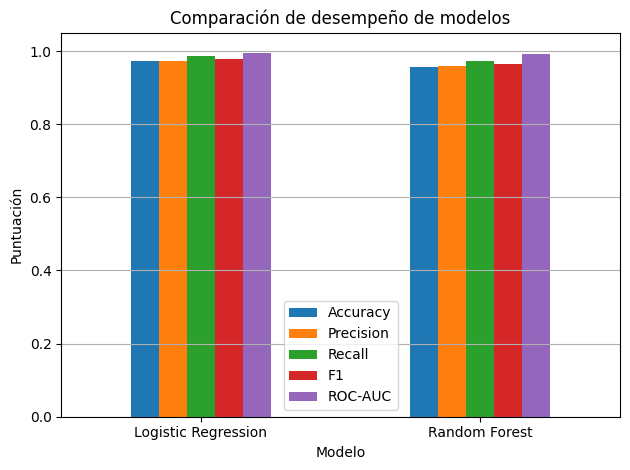

In [11]:

metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

results_plot = results_df.set_index("Modelo")[metrics]

plt.figure(figsize=(10,6))
results_plot.plot(kind="bar")
plt.title("Comparación de desempeño de modelos")
plt.ylabel("Puntuación")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("results/comparacion_modelos.png")
plt.show()

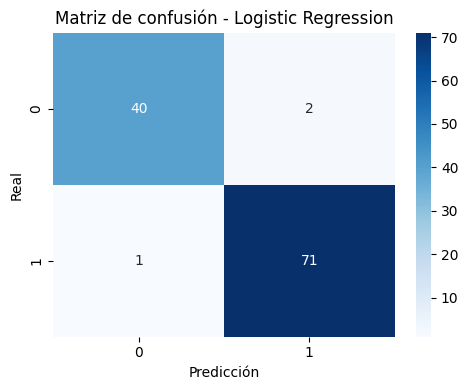

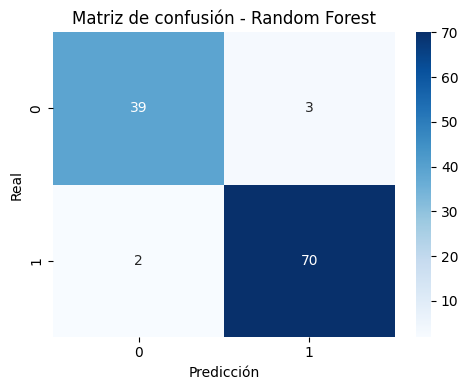

In [12]:

for model_name, config in models.items():
    best_params = results_df.loc[results_df["Modelo"] == model_name, "Best Params"].values[0]

    model = config["pipeline"].set_params(**best_params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de confusión - {model_name}")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.savefig(f"results/matriz_confusion_{model_name.replace(' ', '_').lower()}.png")
    plt.show()

In [13]:

datos_prep_code = '''
import pandas as pd
from sklearn.datasets import load_breast_cancer

def cargar_datos():
    data = load_breast_cancer()
    df = pd.DataFrame(data.data, columns=data.feature_names)
    df["target"] = data.target
    return df

def limpiar_datos(df):
    df_clean = df.copy()
    df_clean = df_clean.drop_duplicates()
    df_clean = df_clean.dropna()
    return df_clean
'''

with open("fuentes/datos_prep.py", "w", encoding="utf-8") as f:
    f.write(datos_prep_code)

print("Archivo fuentes/datos_prep.py creado.")

Archivo fuentes/datos_prep.py creado.


In [14]:

requirements = """mlflow
scikit-learn
pandas
numpy
matplotlib
seaborn
joblib
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt creado")

requirements.txt creado


In [15]:

readme = """# Actividad 5 - MLOps con MLflow

proyecto de clasificación binaria usando el dataset Breast Cancer Wisconsin.

## Modelos entrenados
- Logistic Regression
- Random Forest

## Métricas
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

## Herramientas
- Google Colab
- scikit-learn
- MLflow
- pandas
- matplotlib
- seaborn

## Ejecución
1. Ejecutar el notebook `fuentes/entrena.ipynb`.
2. Generar datasets en `datos/datos_ini` y `datos/datos_limp`.
3. Entrenar modelos con GridSearchCV.
4. Registrar métricas y artefactos en MLflow.
5. Revisar resultados en la carpeta `results`.

## Conclusión
El mejor modelo se selecciona comparando F1-score, ROC-AUC y estabilidad general.
"""

with open("README.md", "w") as f:
    f.write(readme)

print("README.md creado")

README.md creado


In [16]:

changelog = """# CHANGELOG

## Versión 1.0

- Carga del dataset Breast Cancer Wisconsin.
- Guardado de datos originales y datos limpios.
- Limpieza de duplicados y valores nulos.
- Entrenamiento de Logistic Regression.
- Entrenamiento de Random Forest.
- Aplicación de GridSearchCV con validación cruzada.
- Registro de parámetros, métricas y modelos en MLflow.
- Generación de gráficas comparativas y matrices de confusión.
"""

with open("CHANGELOG.md", "w") as f:
    f.write(changelog)

print("CHANGELOG.md creado")

CHANGELOG.md creado


In [17]:

import shutil

shutil.make_archive(
    "Actividad5",
    "zip",
    root_dir=".",
    base_dir="datos"
)

print("ZIP creado correctamente.")

ZIP creado correctamente.
